<a href="https://colab.research.google.com/github/MsSaidat25/AI-Engineer-Projects/blob/main/Spam_Detection_Packt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from wordcloud import WordCloud

In [2]:
# data from:
# https://www.kaggle.com/uciml/sms-spam-collection-dataset
!wget https://lazyprogrammer.me/course_files/spam.csv

--2026-04-27 23:04:55--  https://lazyprogrammer.me/course_files/spam.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 172.67.213.166, 104.21.23.210, 2606:4700:3031::6815:17d2, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|172.67.213.166|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 503663 (492K) [text/csv]
Saving to: ‘spam.csv’

spam.csv            100%[===================>] 491.86K   925KB/s    in 0.5s    

2026-04-27 23:04:56 (925 KB/s) - ‘spam.csv’ saved [503663/503663]



In [3]:
# file contains some invalid chars
# depending on which version of pandas you have
# an error may be thrown
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')

In [5]:
df = df.rename(columns={'v1': 'labels', 'v2': 'data'})
display(df.head())

,labels,data,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
# Drop the unnecessary columns
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], errors='ignore')

In [21]:
df.head()

,labels,data
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [22]:
df['labels'].hist

<bound method hist_series of 0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: labels, Length: 5572, dtype: int64>

In [23]:
# Convert labels to numerical format
df['labels'] = df['labels'].map({'ham': 0, 'spam': 1})

In [9]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['data'], df['labels'], test_size=0.33, random_state=42)

In [10]:
# Vectorize the text data using TF-IDF
vectorizer = TfidfVectorizer(decode_error='ignore')
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

In [25]:
X_train

,data
3235,Aight text me when you're back at mu and I'll ...
945,I cant wait to see you! How were the photos we...
5319,Kothi print out marandratha.
5528,Its just the effect of irritation. Just ignore it
247,Kallis wont bat in 2nd innings.
...,...
3772,I came hostel. I m going to sleep. Plz call me...
5191,"Sorry, I'll call later"
5226,Prabha..i'm soryda..realy..frm heart i'm sory
5390,Nt joking seriously i told


In [26]:
# Train a Multinomial Naive Bayes model
model = MultinomialNB()
model.fit(X_train_vectorized, y_train)

MultinomialNB()

In [12]:
# Make predictions on the test set
y_pred = model.predict(X_test_vectorized)
y_pred_proba = model.predict_proba(X_test_vectorized)[:, 1]

In [29]:
Ptrain = model.predict(X_train_vectorized)
Ptest = model.predict(X_test_vectorized)

In [30]:
# Calculate evaluation metrics
print('ROC AUC Score:', roc_auc_score(y_test, y_pred_proba))
print('F1 Score:', f1_score(y_test, y_pred))

ROC AUC Score: 0.9720946979926185
F1 Score: 0.8251748251748252


In [31]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
display(cm)

array([[1587,    0],
       [  75,  177]])

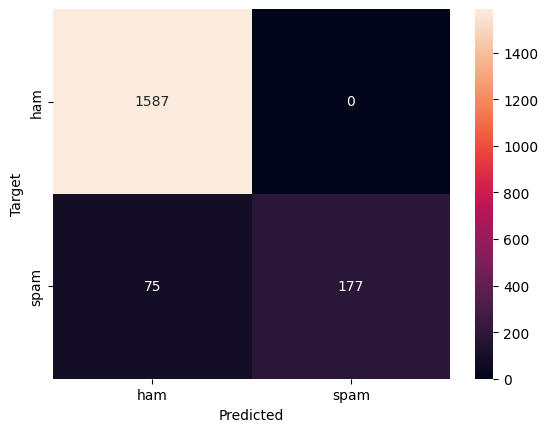

In [32]:
# Scikit-Learn is transitioning to V1 but it's not available on Colab
# The changes modify how confusion matrices are plotted
def plot_cm(cm):
  classes = ['ham', 'spam']
  df_cm = pd.DataFrame(cm, index=classes, columns=classes)
  ax = sn.heatmap(df_cm, annot=True, fmt='g')
  ax.set_xlabel("Predicted")
  ax.set_ylabel("Target")

plot_cm(cm)

In [17]:
# visualize the data
def visualize(label):
  words = ''
  for msg in df[df['labels'] == label]['data']:
    msg = msg.lower()
    words += msg + ' '
  wordcloud = WordCloud(width=600, height=400).generate(words)
  plt.imshow(wordcloud)
  plt.axis('off')
  plt.show()

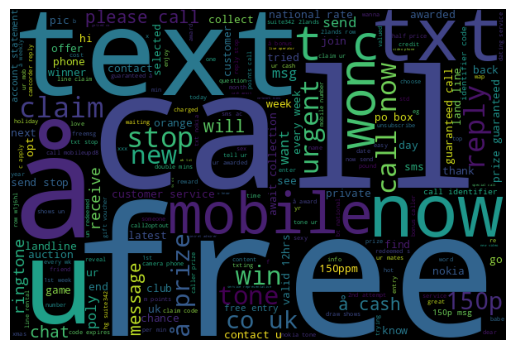

In [19]:
visualize(1)

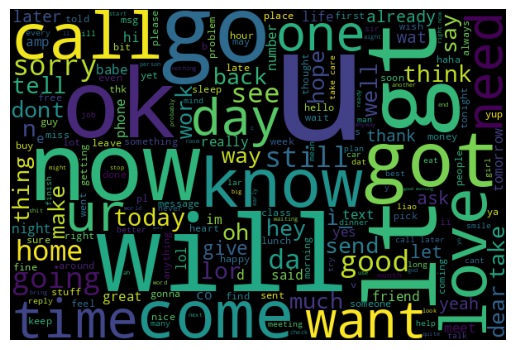

In [20]:
visualize(0)

In [33]:
X = vectorizer.transform(df['data'])
df['predictions'] = model.predict(X)

In [36]:
sneaky_spam = df[(df['predictions'] == 0) & (df['labels'] == 1)]['data']
for msg in sneaky_spam:
  print(msg)

In [38]:
not_actually_spam = df[(df['predictions'] == 1) & (df['labels'] == 0)]['data']

print("--- Debug Information ---")
print(f"Length of not_actually_spam: {len(not_actually_spam)}")
print(f"Unique values in df['labels']: {df['labels'].unique()}")
print(f"Unique values in df['predictions']: {df['predictions'].unique()}")

print("--- Messages (if any) ---")
for msg in not_actually_spam:
  print(msg)

--- Debug Information ---
Length of not_actually_spam: 0
Unique values in df['labels']: [nan]
Unique values in df['predictions']: [0 1]
--- Messages (if any) ---


![](https://deeplearningcourses.com/notebooks_v3_pxl?sc=YGGLcQQmryfSmOWnGm9E6g&n=Spam+Detection)